# Manipulation de données raster en Python

## Objectifs

- Comprendre les bases de la manipulations de données panchromatiques et multispectrales avec Python
- Retrouver les propriétés des images comme avec un logiciel SIG
- Réaliser différentes compositions colorées

Pour la bonne réalisation de ce TP, il est nécessaire d'importer des librairies, offrant des fonctions propres à la manipulations de données rasters (matricielles). La liste des librairies nécessaires vous est donnée ci-dessous.

In [1]:
# Imports indispensables

from matplotlib import pyplot
import rasterio
from rasterio.plot import show
from rasterio.plot import show_hist
from rasterio.plot import adjust_band

### Accès aux images

Il existe différents moyens d'accéder aux données rasters en Python : stockage local ou accès via les bases de données en ligne. Ici, nous allons travailler sur la même données que vous avez récupérée en local et manipulée dans QGIS, mais en y accédant cette-fois ci depuis un cataloque en ligne, sans la télécharger (méthode appelée le "streaming").

Rasterio est une librairie Python qui permet de nombreuse manipulations de rasters, c'est la librairie principale que nous utiliserons pour ce TP. Dans un premier temps, il faut récupérer la donnée raster avec la fonction "open", en l'attribuant à une variable "img".

In [2]:
img = rasterio.open("https://maxar-opendata.s3.amazonaws.com/events/Belize-Wildfires-June24/ard/16/033131010232/2024-05-02/10300100F9791C00-ms.tif")

Vous pouvez maintenant afficher les propriétés de ce raster en tapant simplement le nom de la variable : essayer dans la case ci-dessous !

In [39]:
#Tapez le nom de la variable ici


Que remarquez-vous sur les propriétés affichées ? <span style="color:red"> --> Répondre sur le support de TP </span>

La fonction "show" permet d'afficher l'image. Essayez !

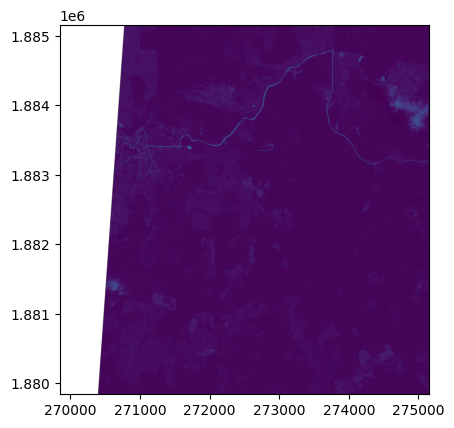

<Axes: >

In [3]:
show(img)

Que remarquerez-vous sur cet affichage : système de coordonnées, emprise de l'image par rapport au graphique, couleurs de l'image, bandes affichées ? <span style="color:red"> --> Répondre sur le support de TP </span>

Pour pouvoir travailler avec les bandes séparement, il faut utiliser la fonction "read" en lui précisant le numéro de la bande voulue : voilà comment accéder à la première bande de l'image et à ses informations.

In [33]:
img.read(1)

array([[  0,   0,   0, ..., 118,  90, 165],
       [  0,   0,   0, ..., 132, 157,  98],
       [  0,   0,   0, ...,  76, 162, 134],
       ...,
       [  0,   0,   0, ..., 290, 359, 247],
       [  0,   0,   0, ..., 345, 316, 147],
       [  0,   0,   0, ..., 350, 204,  96]],
      shape=(2801, 2801), dtype=uint16)

A quel type d'information avez-vous accès grâce à la fonction "read" ? <span style="color:red"> --> Répondre sur le support de TP </span>

Pour simplifier les traitements, le plus simple est de stocker chacune des bandes dans une variable séparées. Par exemple, on pourrait créer une variable "bande-1" qui contiendra la première bande de l'image avec :

In [5]:
bande_1 = img.read(1)

Il est donc possible d'accéder aux mêmes informations que précédemment simplement en tapant le nom de la variable. Vérifiez !

In [38]:
# Tapez le nom de la variable pour l'afficher


De même, il est possible d'afficher uniquement cette bande_1. Comment faire ?

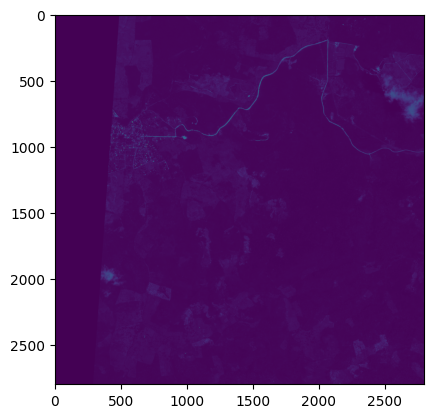

<Axes: >

In [6]:
# Tapez ici
show(bande_1)

Que remarquerez-vous sur l'affichage par défaut de cette bande unique ? <span style="color:red"> --> Répondre sur le support de TP </span>

Différentes options sont disponibles pour améliorer l'affichage des images, notamment des gammes de couleurs par défaut, des "colormap". Par exemple, pour afficher l'image en nuances de gris, il faut ajouter l'option cmap = "gray" dans les paramètres de la fonction.

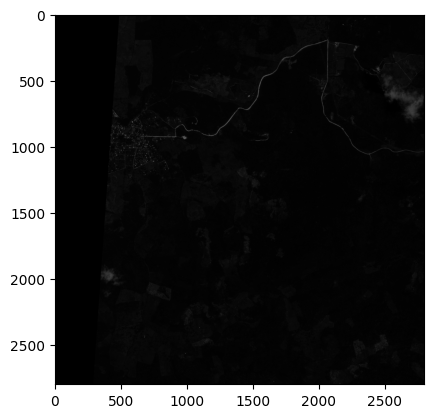

<Axes: >

In [7]:
show(bande_1, cmap = "gray")

Que pensez-vous de l'affichage avec cette nouvelle palette de couleurs ? <span style="color:red"> --> Répondre sur le support de TP </span>

Comme dans QGIS, pour améliorer le contraste, on peut se baser sur l'histogramme. Voilà comment l'afficher pour cette bande.

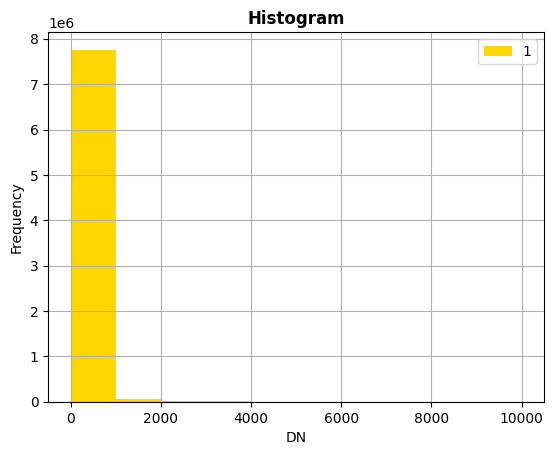

In [8]:
show_hist(bande_1)

Maintenant que la répartition des valeurs est connues, vous pouvez améliorer le contraste de votre image comme sur QGIS, en jouant sur les valeurs min et max de l'affichage. Voilà un premier exemple, modifiez ces valeurs jusqu'à trouver un intervalle qui convienne <span style="color:red"> --> Illustrez votre résultat sur le support de TP en précisant l'intervalle retenu </span>

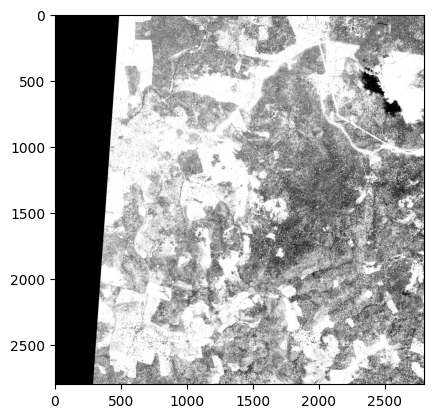

<Axes: >

In [9]:
show(bande_1, vmin=60, vmax=200, cmap = "gray")

Pour définir des noms facilement interprétables de différentes bandes, le mieux est de se référer aux propriétés de celles-ci et de les nommer à partir des domaines de longueurs d'onde dans lesquels chacune des bandes ont acquis de l'information. A partir de https://eoreader.readthedocs.io/latest/_static/optical_band_mapping.html et en sachant qu'il sagit d'une image WorldView-2, quelles sont les noms des domaines de longueurs d'ondes associées au bond numéro de bande ? <span style="color:red"> --> Répondre sur le support de TP </span>

Afin que les noms ne soient pas trop longs, il est préférable de les abréger. De même, plutôt que d'attribuer chaque bande une par une aux variables, nous allons parcourir une liste de toutes les bandes.

In [11]:
deep_b, b, g, y, r, r_edge, nir, water_v = (img.read(i) for i in (1,2,3,4,5,6,7,8))

Affichez les propriétés de la bande verte.

In [60]:
# Tapez ici


Avec la fonction "show" présentée précédemment, il est possible d'afficher plusieurs bandes à la fois, comme dans l'onglet "Symbologie" de QGIS. La fonction "read" peut quant à elle lire plusieurs bandes à la fois en lui fournissant un array d'indices des bandes voulues. Par exemple, pour afficher les bandes 3, 2 et 1 en RGB, voilà comment faire :

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..10000].


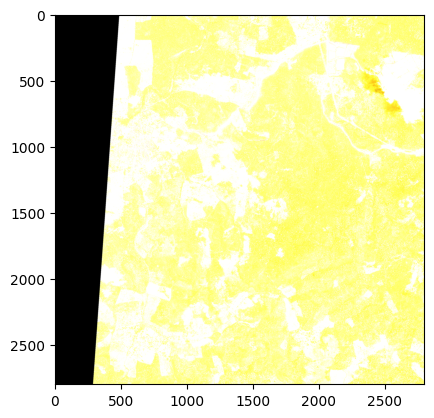

<Axes: >

In [12]:
show(img.read([3,2,1]))

Que remarquez-vous sur ce résultat par rapport à ce que vous obtenez sur QGIS ? A votre avis, pourquoi ? <span style="color:red"> --> Répondre sur le support de TP </span>

Pour que l'affichage de plusieurs bandes simultanément soit correct, une des méthodes possibles est de normaliser les bandes. A quoi correspond cette opération ? <span style="color:red"> --> Répondre sur le support de TP </span>

Avec rasterio, il est possible de normaliser les bandes grâce à la fonction "adjust_band". Visualisez l'histogramme avant et après normalisation.

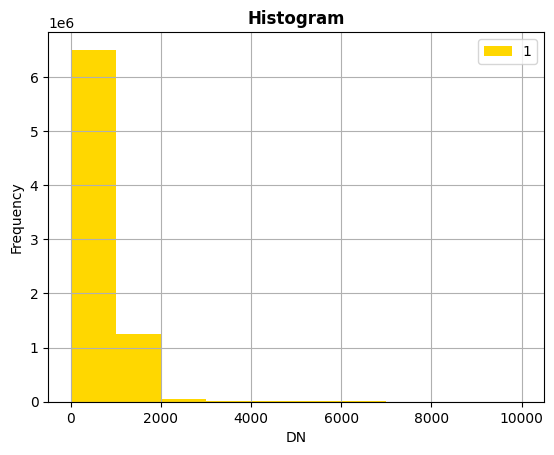

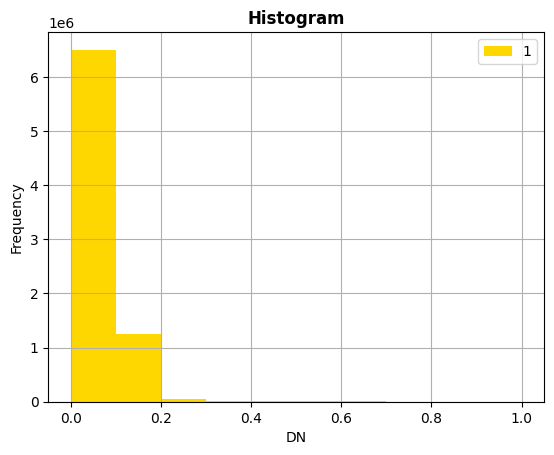

In [13]:
show_hist(img.read(5))
show_hist(adjust_band(img.read(5)))

Commentez ces histogrammes. Lorsque vous avez visualisé les propriétés des bandes, vous avez eu accès à la valeur "dtype" : à quoi correspond "uint16" ? Quel est l'intervalle possible des valeurs ? <span style="color:red"> --> Répondre sur le support de TP </span>

Visualisez maintenant l'image après normalisation des bandes. Que pensez-vous de ce résultat ? <span style="color:red"> --> Répondez et illustrez votre résultat sur le support de TP avec la fonction utilisée </span>

In [101]:
# Affichez l'image en composition RGB


Si nécessaire, ajustez le contraste en modifiant les valeurs minimales et maximales <span style="color:red"> --> Illustrez votre résultat sur le support de TP en précisant l'intervalle retenu </span>

In [106]:
# Affichez l'image en composition RGB avec un contraste adapté


Affichez maintenant l'image de manière à ce que la végétation apparaisse rouge. <span style="color:red"> --> Illustrez votre résultat sur le support de TP en précisant les bandes utilisées </span>

In [100]:
# Affichez l'image avec la végétation en rouge


### Pour aller plus loin

Si vous le souhaitez, vous pouvez essayer de calculer le NDVI de cette image et de l'afficher.